In [1]:
import pandas as pd

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')
print(df)

if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:

    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")
# Extract gene and score
result = df[['gene_symbol', score_col]]

# Sort by score in descending order
result = result.sort_values(by=score_col, ascending=False)

# Display the result
print(result)

# Save to a CSV file
result.to_csv('mdd_genes_with_scores.csv', index=False)

import pandas as pd

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')

# Identify the score column
if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:
    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")

# Filter for genes with score >= 0.65
high_score_genes = df[df[score_col] >= 0.70].copy()

# Extract gene and score
filtered_result = high_score_genes[['gene_symbol', score_col]]

# Sort by score in descending order
filtered_result = filtered_result.sort_values(by=score_col, ascending=False)

# Display the result
print(f"Found {len(filtered_result)} genes with score >= 0.70")
#print((filtered_result))

pd.set_option('display.max_rows', None)

# Print only the desired columns
print(filtered_result)
# Save to a CSV file
#filtered_result.to_csv('mdd_genes_high_score.csv', index=False)

# Optional: Add a label column
filtered_result['MDD_Label'] = 'High_Confidence_MDD_Gene'

# Save the labeled version
#result.to_csv('mdd_genes_high_score_labeled.csv', index=False)

           ei  numCTs                                       pathway_name  \
0    0.903846       2                                Signal Transduction   
1    0.830645      68  Signal Transduction,Disease,Immune System,Meta...   
2    0.871642      64  Signal Transduction,Disease,Gene expression (T...   
3    0.855556       6                                    Neuronal System   
4    0.764151      44                                      Immune System   
..        ...     ...                                                ...   
224  1.000000       0                                                NaN   
225  1.000000       0                                                NaN   
226  1.000000       0                              Developmental Biology   
227  1.000000       0          Developmental Biology,Signal Transduction   
228  1.000000       0  Metabolism of proteins,Cellular responses to s...   

    gene_symbol  numVariantsAssociatedToGene              gp_class_names  \
0         H

COMPREHENSIVE ANALYSIS OF MDD CANDIDATE GENES

1. BASIC STATISTICS
----------------------------------------
Total number of genes: 229
Average score: 0.624
Median score: 0.600
Score standard deviation: 0.119
Minimum score: 0.500
Maximum score: 0.950

2. SCORE DISTRIBUTION BY QUANTILES
----------------------------------------
25th percentile: 0.500
50th percentile: 0.600
75th percentile: 0.700
90th percentile: 0.800
95th percentile: 0.850

3. GENE COUNT BY SCORE THRESHOLDS
----------------------------------------
Genes with score ≥ 0.3: 229 (100.0%)
Genes with score ≥ 0.5: 229 (100.0%)
Genes with score ≥ 0.7: 62 (27.1%)
Genes with score ≥ 0.8: 33 (14.4%)
Genes with score ≥ 0.9: 6 (2.6%)

4. TOP 10 HIGHEST SCORING GENES
----------------------------------------
HTR1A: 0.950
IL6: 0.950
BDNF: 0.950
SLC6A4: 0.950
CRP: 0.950
GRM5: 0.900
CRH: 0.850
CYP2C19: 0.850
CYP2D6: 0.850
NR3C1: 0.850

5. GENERATING VISUALIZATIONS
----------------------------------------
Visualizations saved as 'mdd_genes

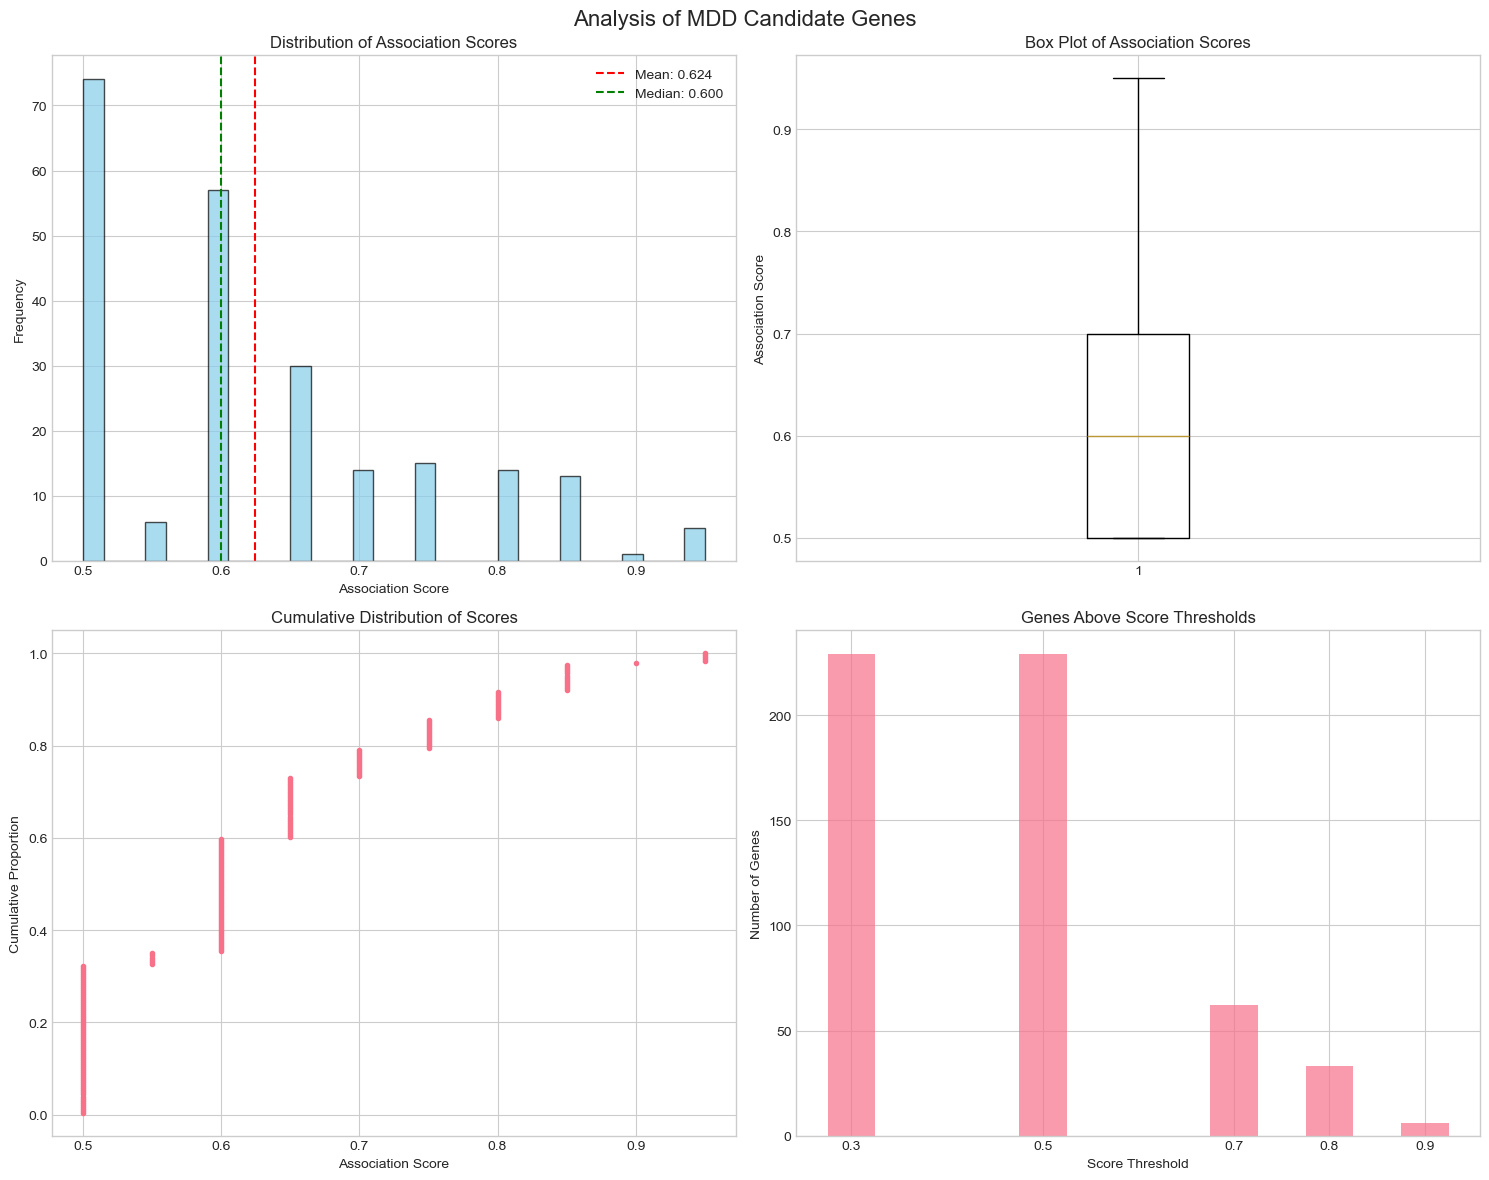

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def analyze_mdd_genes(df, score_column='score'):
    """
    Perform comprehensive analysis on MDD candidate genes
    
    Parameters:
    df (DataFrame): DataFrame containing MDD genes and their scores
    score_column (str): Name of the column containing association scores
    """
    
    print("=" * 60)
    print("COMPREHENSIVE ANALYSIS OF MDD CANDIDATE GENES")
    print("=" * 60)
    
    # 1. Basic statistics
    print("\n1. BASIC STATISTICS")
    print("-" * 40)
    print(f"Total number of genes: {len(df)}")
    print(f"Average score: {df[score_column].mean():.3f}")
    print(f"Median score: {df[score_column].median():.3f}")
    print(f"Score standard deviation: {df[score_column].std():.3f}")
    print(f"Minimum score: {df[score_column].min():.3f}")
    print(f"Maximum score: {df[score_column].max():.3f}")
    
    # 2. Score distribution by quantiles
    print("\n2. SCORE DISTRIBUTION BY QUANTILES")
    print("-" * 40)
    quantiles = df[score_column].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
    for q, value in quantiles.items():
        print(f"{int(q*100)}th percentile: {value:.3f}")
    
    # 3. Count genes by score thresholds
    print("\n3. GENE COUNT BY SCORE THRESHOLDS")
    print("-" * 40)
    thresholds = [0.3, 0.5, 0.7, 0.8, 0.9]
    for threshold in thresholds:
        count = len(df[df[score_column] >= threshold])
        print(f"Genes with score ≥ {threshold}: {count} ({count/len(df)*100:.1f}%)")
    
    # 4. Top 10 highest scoring genes
    print("\n4. TOP 10 HIGHEST SCORING GENES")
    print("-" * 40)
    top_genes = df.nlargest(10, score_column)[['gene_symbol', score_column]]
    for _, row in top_genes.iterrows():
        print(f"{row['gene_symbol']}: {row[score_column]:.3f}")
    
    # 5. Visualizations
    print("\n5. GENERATING VISUALIZATIONS")
    print("-" * 40)
    
    # Create a figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Analysis of MDD Candidate Genes', fontsize=16)
    
    # Distribution of scores
    axes[0, 0].hist(df[score_column], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(df[score_column].mean(), color='red', linestyle='--', label=f'Mean: {df[score_column].mean():.3f}')
    axes[0, 0].axvline(df[score_column].median(), color='green', linestyle='--', label=f'Median: {df[score_column].median():.3f}')
    axes[0, 0].set_xlabel('Association Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Association Scores')
    axes[0, 0].legend()
    
    # Box plot of scores
    axes[0, 1].boxplot(df[score_column])
    axes[0, 1].set_ylabel('Association Score')
    axes[0, 1].set_title('Box Plot of Association Scores')
    
    # Cumulative distribution
    sorted_scores = np.sort(df[score_column])
    cum_dist = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
    axes[1, 0].plot(sorted_scores, cum_dist, marker='.', linestyle='none')
    axes[1, 0].set_xlabel('Association Score')
    axes[1, 0].set_ylabel('Cumulative Proportion')
    axes[1, 0].set_title('Cumulative Distribution of Scores')
    axes[1, 0].grid(True)
    
    # Score thresholds
    threshold_counts = [len(df[df[score_column] >= t]) for t in thresholds]
    axes[1, 1].bar(thresholds, threshold_counts, width=0.05, alpha=0.7)
    axes[1, 1].set_xlabel('Score Threshold')
    axes[1, 1].set_ylabel('Number of Genes')
    axes[1, 1].set_title('Genes Above Score Thresholds')
    axes[1, 1].set_xticks(thresholds)
    
    plt.tight_layout()
    plt.savefig('mdd_genes_analysis.png', dpi=300, bbox_inches='tight')
    print("Visualizations saved as 'mdd_genes_analysis.png'")
    
    # 6. Additional analyses if other columns are available
    if 'Gene Type' in df.columns:
        print("\n6. GENE TYPE DISTRIBUTION")
        print("-" * 40)
        gene_type_counts = df['Gene Type'].value_counts()
        print("Top gene types:")
        for gene_type, count in gene_type_counts.head(10).items():
            print(f"  {gene_type}: {count} genes")
            
        # Plot gene type distribution
        plt.figure(figsize=(10, 6))
        gene_type_counts.head(10).plot(kind='bar', color='lightcoral')
        plt.title('Top 10 Gene Types in MDD Candidates')
        plt.xlabel('Gene Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('mdd_gene_types.png', dpi=300, bbox_inches='tight')
        print("Gene type distribution saved as 'mdd_gene_types.png'")
    
    if 'Pathways' in df.columns:
        print("\n7. PATHWAY ANALYSIS")
        print("-" * 40)
        # Extract and count pathways
        all_pathways = []
        for pathways in df['Pathways'].dropna():
            # Assuming pathways are separated by semicolons
            pathway_list = [p.strip() for p in pathways.split(';')]
            all_pathways.extend(pathway_list)
        
        pathway_counts = pd.Series(all_pathways).value_counts()
        print("Top pathways associated with MDD genes:")
        for pathway, count in pathway_counts.head(10).items():
            print(f"  {pathway}: {count} genes")
    
    # 8. Save detailed analysis results
    analysis_results = {
        'total_genes': len(df),
        'mean_score': df[score_column].mean(),
        'median_score': df[score_column].median(),
        'std_score': df[score_column].std(),
        'min_score': df[score_column].min(),
        'max_score': df[score_column].max(),
        'quantiles': quantiles.to_dict(),
        'threshold_counts': {f"geq_{t}": len(df[df[score_column] >= t]) for t in thresholds},
        'top_genes': top_genes.to_dict('records')
    }
    
    # Convert to DataFrame and save
    analysis_df = pd.DataFrame.from_dict(analysis_results, orient='index')
    analysis_df.to_csv('mdd_genes_analysis_summary.csv', header=['Value'])
    print("\nAnalysis summary saved as 'mdd_genes_analysis_summary.csv'")
    
    return analysis_results

# Load your data
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')

# Identify the score column
if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:
    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")

# Run the analysis
analysis_results = analyze_mdd_genes(df, score_col)

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

In [4]:
import pandas as pd

pd.reset_option('display.max_rows')

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_97.tsv" 
brain_only_df = pd.read_csv(file_path, sep='\t')


brain_only_df = brain_only_df[['Gene']]


# Display the result
print("The genes that only exist in human's brain:")
print(brain_only_df)

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_restrictedbrain.tsv" 
brain_restricted_df = pd.read_csv(file_path, sep='\t')


brain_restricted_df = brain_restricted_df[['Gene']]


# Display the result
print("The genes that only exist in human's brain and in less than 1/3 of other tissues:")
print(brain_restricted_df)


# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_all_tissues.tsv" 
all_tissues_df = pd.read_csv(file_path, sep='\t')


all_tissues_df = all_tissues_df[['Gene']]


# Display the result
print("The genes that exist in human's brain and other tissues (more than 1/3 of other tissues):")
print(all_tissues_df)



print('List of common genes between all MDD genes and the genes only existing in brain are:')
common_df = result[result['gene_symbol'].isin(brain_only_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes only existing in brain are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(brain_only_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print("-------------------------------------------------")
print('List of common genes between all MDD genes and the genes in brain and in less than 1/3 other tissues are:')
common_df = result[result['gene_symbol'].isin(brain_restricted_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes existing brain and less than 1/3 of all tissues are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(brain_restricted_df['Gene'])]
print(common_df)
print(len(common_df))

print("\n \n")
print("-------------------------------------------------")
print('List of common genes between all MDD genes and the genes in brain and in more than 1/3 other tissues are:')
common_df = result[result['gene_symbol'].isin(all_tissues_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes in more than 1/3 of all tissues are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(all_tissues_df['Gene'])]
print(common_df)
print(len(common_df))



#concat MDD genes with Brain genes
import pandas as pd

print("Node set 1 contains the restricted genes (Genes in brain and less than 1/3 of all tissues + Genes only in brain:)")
node_set1 = pd.DataFrame({
    'Genes': pd.concat([
        result['gene_symbol'], 
        brain_restricted_df['Gene']
    ], ignore_index=True)
})

node_set1 = pd.DataFrame({
    'Genes': pd.concat([
        node_set1['Genes'], 
        brain_only_df['Gene']
    ], ignore_index=True)
})
print(node_set1)


print("----------------------")
print("\n")

print("Node set 2 contains the all brain genes (And all other tissues))")
node_set2 = pd.DataFrame({
    'Genes': pd.concat([
        all_tissues_df['Gene'], 
        node_set1['Genes']
    ], ignore_index=True)
})
print(node_set2)

print("----------------------")
print("\n")

print("Here the node set is assigned to the nodes in our network: ")
all_nodes = node_set1

print(all_nodes)



import requests

# Gene list
gene_list = all_nodes['Genes'].dropna().unique().tolist()
print(f"Number of input genes: {len(gene_list)}")

# STRING API settings
STRING_API_URL = "https://string-db.org/api/tsv-no-header/network"
payload = {
    "identifiers": "\n".join(gene_list),  # newline-separated
    "species": 9606,
    "required_score": 400
}

# Use POST to avoid URL length limit
response = requests.post(STRING_API_URL, data=payload)

if response.ok:
    interactions = []
    for line in response.text.strip().split("\n"):
        cols = line.split("\t")
        try:
            gene_a = cols[2]  # preferredName_A
            gene_b = cols[3]  # preferredName_B
            
            score = float(cols[5])  # combined_score
            interactions.append((gene_a, gene_b, score))
           # print(interactions)
        except (IndexError, ValueError):
            continue
    print(f"Number of interactions found: {len(interactions)}")
else:
    print("Error:", response.status_code, response.text)

for i in range(0,10):
    print(interactions[i])


import networkx as nx

G = nx.Graph()

# Add nodes
G.add_nodes_from(gene_list)

# Add edges with STRING score as weight
for gene_a, gene_b, score in interactions:
    G.add_edge(gene_a, gene_b, weight=score)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")



The genes that only exist in human's brain:
              Gene
0             AMBN
1             AMZ1
2         ANKRD34C
3          ANKRD63
4   ARMCX5-GPRASP2
..             ...
92        TMEM132D
93           TRPC5
94            UCMA
95            VAX1
96            WNT1

[97 rows x 1 columns]
The genes that only exist in human's brain and in less than 1/3 of other tissues:
         Gene
0       A2ML1
1      ABCC12
2       ABCG4
3     ABHD12B
4        ACAN
...       ...
1359   ZNF732
1360  ZNF804A
1361   ZNF831
1362   ZNF843
1363      ZP2

[1364 rows x 1 columns]
The genes that exist in human's brain and other tissues (more than 1/3 of other tissues):
        Gene
0     A4GALT
1      AADAT
2       AARD
3       AASS
4       AATK
...      ...
4966  ZSWIM4
4967  ZSWIM5
4968  ZSWIM9
4969   ZWINT
4970    ZXDA

[4971 rows x 1 columns]
List of common genes between all MDD genes and the genes only existing in brain are:
    gene_symbol  score
93         DRD3    0.6
111       HTR3B    0.6
118  

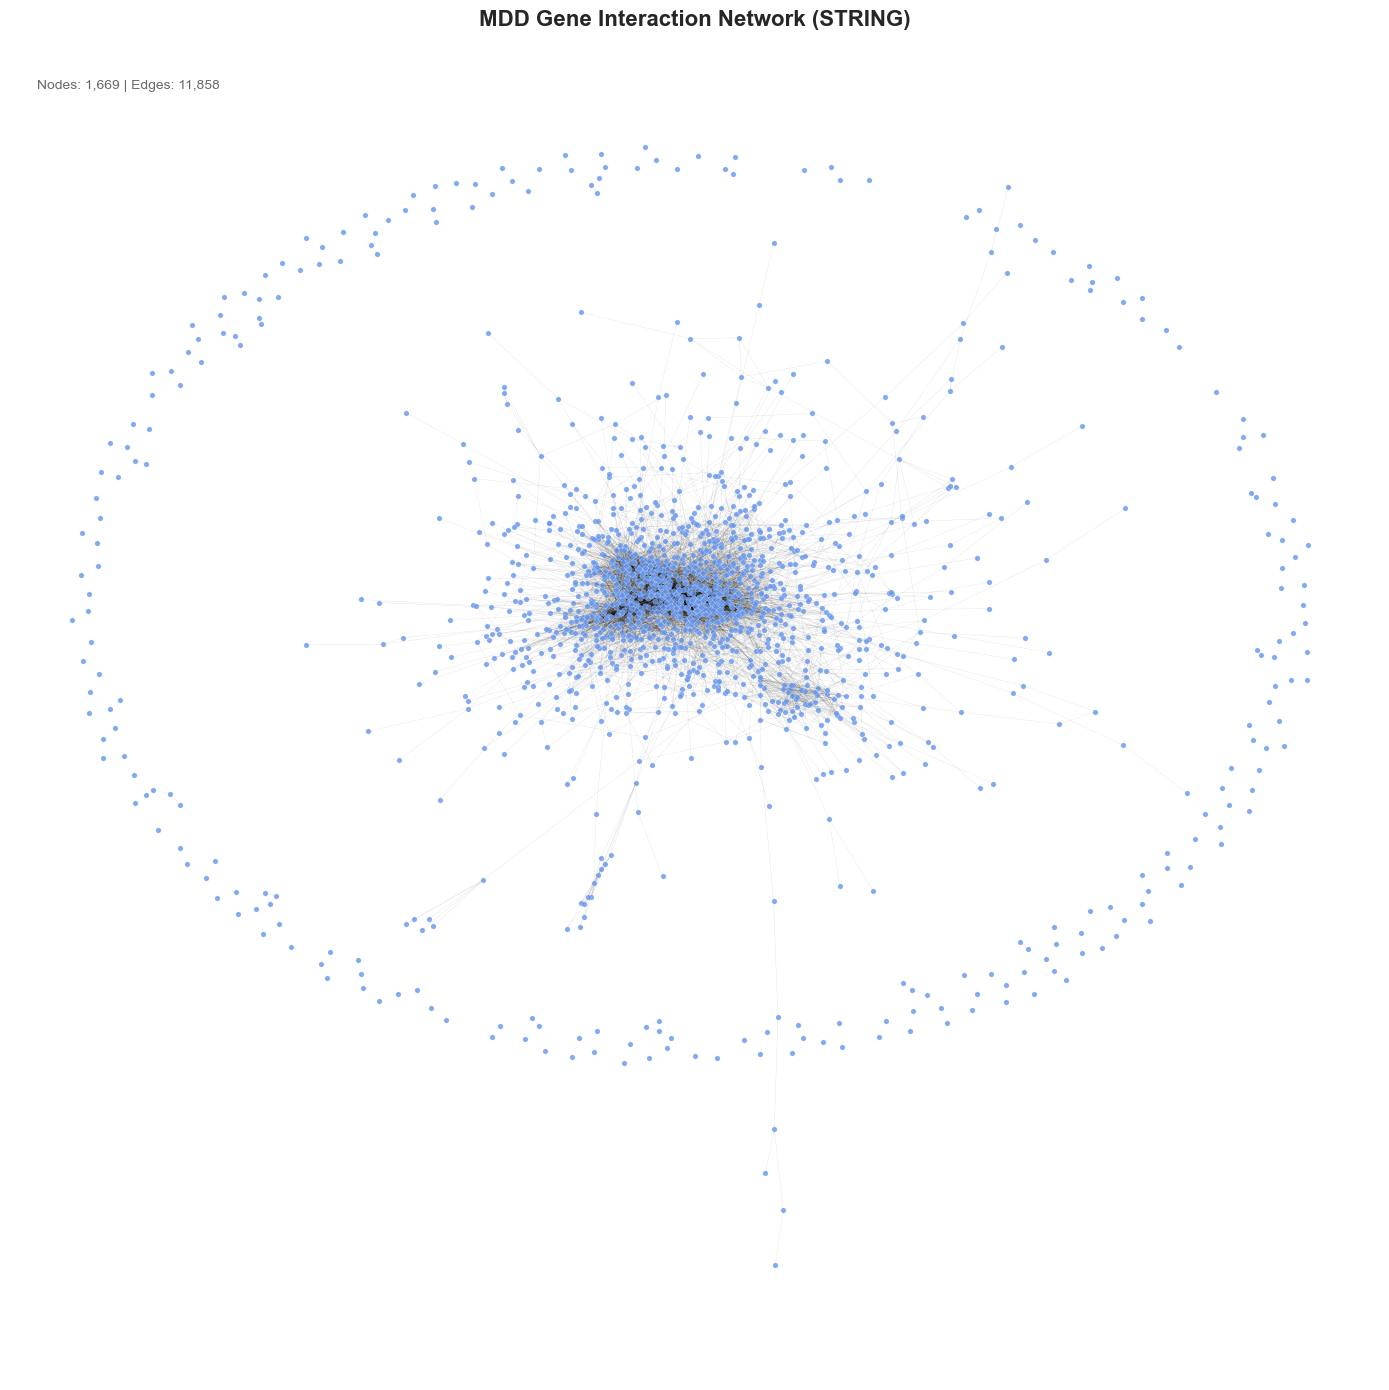

In [5]:
#Another graph!
import matplotlib.pyplot as plt
import networkx as nx

# Set style for cleaner look
plt.style.use("seaborn-v0_8-white")

# Create the layout (spring layout can be slow, so this uses fewer iterations)
pos = nx.spring_layout(G, k=0.08, iterations=50, seed=42)

# Initialize figure
plt.figure(figsize=(14, 14))
plt.title("MDD Gene Interaction Network (STRING)", fontsize=16, fontweight='bold', pad=20)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=15,
    node_color="cornflowerblue",
    alpha=0.8,
    linewidths=0.2,
    edgecolors="white"
)

# Draw edges (thin and transparent for clarity)
nx.draw_networkx_edges(
    G, pos,
    width=0.2,
    alpha=0.15,
    edge_color="black"
)

# Remove axes for a clean look
plt.axis("off")

# Add annotation for node/edge count
plt.text(0.02, 0.98,
         f"Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}",
         transform=plt.gca().transAxes,
         fontsize=10, color="dimgray", va="top")

plt.tight_layout()
plt.show()


In [6]:
# ============================================================
# NETWORK STRUCTURE SUMMARY (for thesis reporting)
# Assumes you already have a NetworkX graph object named `G`
# Works for undirected weighted PPI graphs (STRING scores as weights)
# ============================================================

import numpy as np
import networkx as nx
import pandas as pd

if "G" not in globals():
    raise NameError("G not found. Please make sure your NetworkX graph is saved as variable `G`.")

if not isinstance(G, (nx.Graph, nx.DiGraph)):
    raise TypeError(f"G must be a NetworkX graph. Got: {type(G)}")

is_directed = G.is_directed()
n = G.number_of_nodes()
m = G.number_of_edges()

print("=== NETWORK STRUCTURE SUMMARY ===")
print(f"Graph type: {'Directed' if is_directed else 'Undirected'} | Weighted: {'Yes' if nx.is_weighted(G) else 'No'}")
print(f"Nodes (genes): {n:,}")
print(f"Edges (PPIs):  {m:,}")

if n == 0:
    raise RuntimeError("Graph has 0 nodes.")

# ----------------------------
# Basic density and degree stats
# ----------------------------
density = nx.density(G)
deg = dict(G.degree())
deg_vals = np.array(list(deg.values()), dtype=float)

avg_deg = float(deg_vals.mean())
med_deg = float(np.median(deg_vals))
max_deg = int(deg_vals.max())
p95_deg = float(np.quantile(deg_vals, 0.95)) if n >= 2 else float(deg_vals[0])

print("\n--- Basic connectivity ---")
print(f"Density: {density:.6g}")
print(f"Average degree: {avg_deg:.3f} | Median degree: {med_deg:.1f} | 95th pct degree: {p95_deg:.1f} | Max degree: {max_deg}")

# Weighted degree ("strength") if weights exist
has_weight = any("weight" in G[u][v] for u, v in G.edges()) if m > 0 else False
if has_weight:
    wdeg = dict(G.degree(weight="weight"))
    wdeg_vals = np.array(list(wdeg.values()), dtype=float)
    print("\n--- Weighted connectivity (strength) ---")
    print(
        f"Average weighted degree: {wdeg_vals.mean():.3f} | Median: {np.median(wdeg_vals):.3f} | "
        f"95th pct: {np.quantile(wdeg_vals, 0.95):.3f} | Max: {wdeg_vals.max():.3f}"
    )
else:
    wdeg = None

# ----------------------------
# Components / fragmentation
# ----------------------------
print("\n--- Components ---")
if not is_directed:
    comps = list(nx.connected_components(G))
    comp_sizes = np.array([len(c) for c in comps], dtype=int)
    n_comp = len(comp_sizes)
    largest_size = int(comp_sizes.max())
    frac_lcc = largest_size / n

    isolates = list(nx.isolates(G))
    print(f"Connected components: {n_comp}")
    print(f"Largest connected component (LCC): {largest_size:,} nodes ({frac_lcc:.2%} of all nodes)")
    print(f"Isolated nodes (degree=0): {len(isolates):,}")
else:
    # For directed graphs, report weakly connected components
    comps = list(nx.weakly_connected_components(G))
    comp_sizes = np.array([len(c) for c in comps], dtype=int)
    n_comp = len(comp_sizes)
    largest_size = int(comp_sizes.max())
    frac_lcc = largest_size / n

    isolates = [v for v in G.nodes() if G.in_degree(v) == 0 and G.out_degree(v) == 0]
    print(f"Weakly connected components: {n_comp}")
    print(f"Largest weakly connected component: {largest_size:,} nodes ({frac_lcc:.2%} of all nodes)")
    print(f"Isolated nodes: {len(isolates):,}")

# Build subgraph of the largest component for some metrics
largest_comp_nodes = max(comps, key=len)
H = G.subgraph(largest_comp_nodes).copy()

# ----------------------------
# Clustering and assortativity
# ----------------------------
print("\n--- Local structure ---")
try:
    avg_clust = nx.average_clustering(H) if not H.is_directed() else nx.average_clustering(H.to_undirected())
    print(f"Average clustering coefficient (LCC): {avg_clust:.4f}")
except Exception as e:
    print(f"Average clustering coefficient (LCC): could not compute ({type(e).__name__})")

try:
    # Degree assortativity can be unstable for small graphs
    assort = nx.degree_assortativity_coefficient(H.to_undirected() if H.is_directed() else H)
    if np.isnan(assort):
        print("Degree assortativity (LCC): NaN (not well-defined for this graph)")
    else:
        print(f"Degree assortativity (LCC): {assort:.4f}")
except Exception as e:
    print(f"Degree assortativity (LCC): could not compute ({type(e).__name__})")

# ----------------------------
# Path-based summary (unweighted) on LCC
# ----------------------------
print("\n--- Global distances (unweighted; LCC) ---")
try:
    # Average shortest path length can be expensive; compute only on LCC
    asp = nx.average_shortest_path_length(H.to_undirected() if H.is_directed() else H)
    print(f"Average shortest path length: {asp:.3f}")
except Exception as e:
    print(f"Average shortest path length: could not compute ({type(e).__name__})")

try:
    diam = nx.diameter(H.to_undirected() if H.is_directed() else H)
    print(f"Diameter: {diam}")
except Exception as e:
    print(f"Diameter: could not compute ({type(e).__name__})")

# ----------------------------
# Edge-weight distribution
# ----------------------------
print("\n--- Edge weights ---")
if has_weight and m > 0:
    w = np.array([float(G[u][v].get("weight", np.nan)) for u, v in G.edges()], dtype=float)
    w = w[~np.isnan(w)]
    if w.size:
        q01, q25, q50, q75, q99 = np.quantile(w, [0.01, 0.25, 0.50, 0.75, 0.99])
        print(
            f"Weight stats: n={w.size:,} | min={w.min():.4f} | p01={q01:.4f} | "
            f"p25={q25:.4f} | median={q50:.4f} | p75={q75:.4f} | p99={q99:.4f} | max={w.max():.4f}"
        )
    else:
        print("Edge weights present but could not read numeric values.")
else:
    print("No edge weights found (or graph has no edges).")

# ----------------------------
# Top hubs (degree and weighted degree)
# ----------------------------
print("\n--- Top hub genes ---")
top_k = 10
deg_sorted = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:top_k]
print("Top by degree:")
for g, d in deg_sorted:
    print(f"  {g:>12s}  degree={int(d)}")

if has_weight:
    wdeg_sorted = sorted(wdeg.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print("\nTop by weighted degree (strength):")
    for g, s in wdeg_sorted:
        print(f"  {g:>12s}  strength={float(s):.4f}")

# ----------------------------
# Thesis-friendly context text (you can paste into your thesis)
# ----------------------------
print("\n=== THESIS-READY CONTEXT (DRAFT) ===")
context_lines = []
context_lines.append(
    f"The constructed protein--protein interaction graph contains {n:,} nodes (genes) and {m:,} weighted edges."
)
if not is_directed:
    context_lines.append(
        f"The graph is sparse (density={density:.3g}) and exhibits a hub-like degree distribution "
        f"(mean degree={avg_deg:.2f}, max degree={max_deg})."
    )
else:
    context_lines.append(
        f"The graph is sparse (density={density:.3g}) with mean total degree {avg_deg:.2f} and max total degree {max_deg}."
    )
context_lines.append(
    f"Most nodes are contained in the largest connected component ({H.number_of_nodes():,} nodes; {H.number_of_nodes()/n:.1%}), "
    "supporting the use of network-based proximity and graph-learning methods."
)
try:
    if 'avg_clust' in locals() and isinstance(avg_clust, (float, np.floating)):
        context_lines.append(
            f"Local connectivity shows non-trivial clustering (average clustering coefficient in the LCC={avg_clust:.3f}), "
            "consistent with modular structure commonly observed in biological networks."
        )
except Exception:
    pass
if has_weight and m > 0 and "w" in locals() and w.size:
    context_lines.append(
        f"Edge weights (STRING confidence scores) span a range with median {np.median(w):.3f}, indicating graded interaction support "
        "that can be retained as continuous evidence in downstream analyses."
    )

print("\n".join(context_lines))

# Optional: export a small table of summary stats for your notes
summary = {
    "nodes": n,
    "edges": m,
    "directed": bool(is_directed),
    "weighted": bool(has_weight),
    "density": float(density),
    "avg_degree": float(avg_deg),
    "median_degree": float(med_deg),
    "p95_degree": float(p95_deg),
    "max_degree": int(max_deg),
    "num_components": int(len(comps)),
    "lcc_nodes": int(H.number_of_nodes()),
    "lcc_fraction": float(H.number_of_nodes() / n),
    "isolates": int(len(isolates)),
}
if has_weight and wdeg is not None:
    summary["avg_weighted_degree"] = float(np.mean(list(wdeg.values())))
if has_weight and m > 0 and "w" in locals() and w.size:
    summary["median_weight"] = float(np.median(w))
    summary["min_weight"] = float(w.min())
    summary["max_weight"] = float(w.max())

summary_df = pd.DataFrame([summary])
print("\n=== SUMMARY TABLE (copy/paste or save) ===")
print(summary_df.to_string(index=False))


=== NETWORK STRUCTURE SUMMARY ===
Graph type: Undirected | Weighted: Yes
Nodes (genes): 1,669
Edges (PPIs):  11,858

--- Basic connectivity ---
Density: 0.00851901
Average degree: 14.210 | Median degree: 6.0 | 95th pct degree: 59.0 | Max degree: 163

--- Weighted connectivity (strength) ---
Average weighted degree: 8.235 | Median: 3.068 | 95th pct: 34.439 | Max: 102.372

--- Components ---
Connected components: 233
Largest connected component (LCC): 1,418 nodes (84.96% of all nodes)
Isolated nodes (degree=0): 217

--- Local structure ---
Average clustering coefficient (LCC): 0.2958
Degree assortativity (LCC): 0.2194

--- Global distances (unweighted; LCC) ---
Average shortest path length: 3.678
Diameter: 13

--- Edge weights ---
Weight stats: n=11,858 | min=0.4000 | p01=0.4010 | p25=0.4510 | median=0.5300 | p75=0.6690 | p99=0.9960 | max=0.9990

--- Top hub genes ---
Top by degree:
          BDNF  degree=163
        GRIN2B  degree=142
           TNF  degree=131
          DLG4  degree=12

Initial STRING graph: 1020 nodes, 4198 edges
Positive genes in graph before component filtering: 60
Removed 86 genes from components with no positive connection
Filtered graph: 934 nodes, 4150 edges
Positive genes in filtered graph: 60
Scoring table built: 934 nodes (positives=60)

NEGATIVE SELECTION (30 samples; criteria identical, seed varies)
- Non-positives count: 874
- Bottom quantile q=0.5: cutoff=0.284260
- Exclude dist <= 2: ON
- Eligible negatives: 215
- Selected negatives per sample: 60 (target=60)
- Positives in graph: 60
- Negative sampling seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
  sample 00 seed=42: size=60 | outside_eligible=0 | overlap_positives=0
  sample 01 seed=43: size=60 | outside_eligible=0 | overlap_positives=0
  sample 02 seed=44: size=60 | outside_eligible=0 | overlap_positives=0
  sample 03 seed=45: size=60 | outside_eligible=0 | overlap_positives=0
  sample 04 seed=46: size

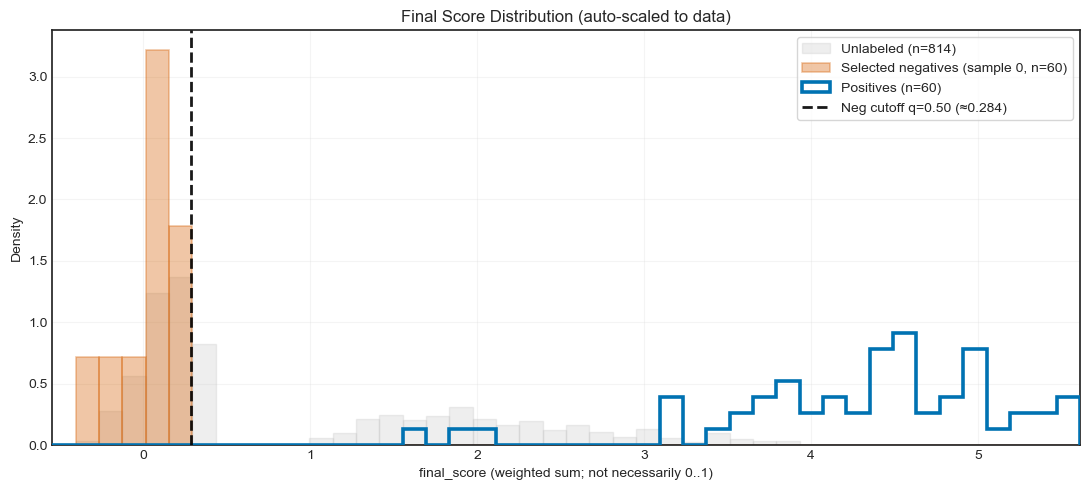

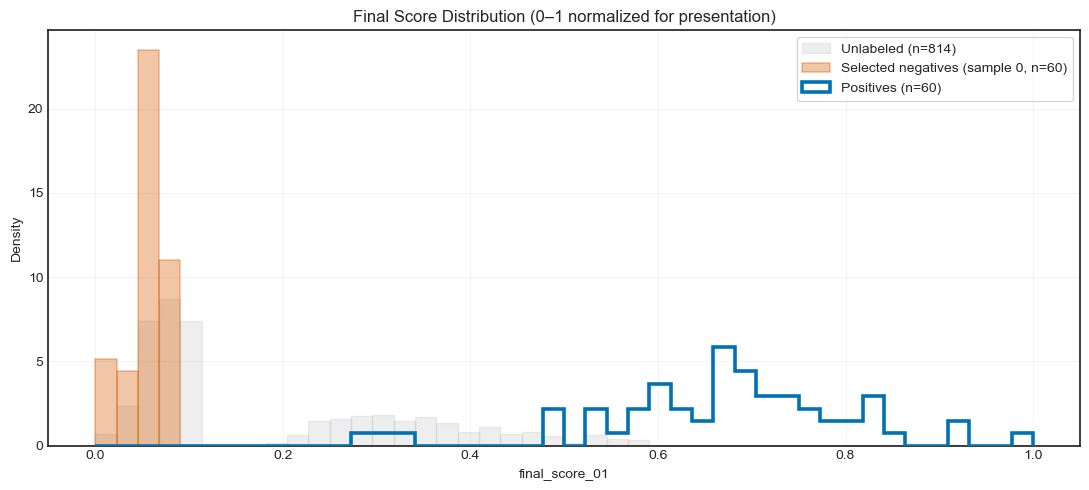

/var/folders/ql/zn64c29n0xbcthrddtdp57_m0000gn/T/ipykernel_97308/403279947.py:356: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


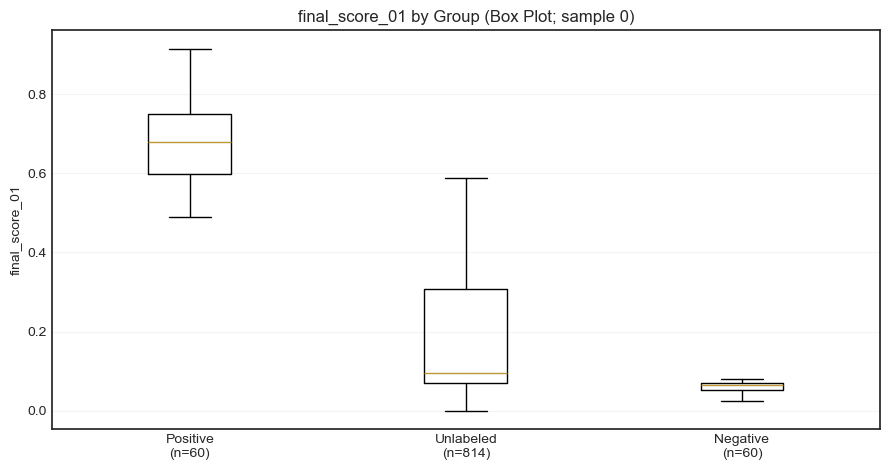


Saved:
- candidate_genes.csv (top 20 non-positive by final_score)
- refined_negative_genes_30samples_thr0.6_q0.5_excl2_k60.csv
- refined_negative_genes_SAMPLE0_thr0.6_q0.5_excl2.csv
- scored_all_nodes.csv (all nodes with features + scores + groups)


In [13]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import random
from collections import deque

# =======================================================
# FULL PIPELINE: Heuristic Scoring + Negative Selection (30 samples)
#
# IMPORTANT:
# - negatives are sampled ONLY from non-positives
# - eligible pool = bottom NEG_Q of non-positive final_score
# - optionally exclude nodes within <= EXCLUDE_DIST hops of positives
#
# CHANGES IN THIS VERSION:
# 1) keep only the part of the graph connected to at least one positive gene
# 2) generate 30 negative samples
# 3) match negatives to number of positives in the filtered graph
# 4) sort eligible genes before sampling for stable reproducibility
# =======================================================

# -----------------------------
# Config
# -----------------------------
EDGE_THRESHOLD = 0.6

NEG_Q = 0.50
EXCLUDE_DIST = 2

N_NEG_SAMPLES = 30
BASE_SEED = 42

WEIGHTS = {
    "ppr": 3.0,
    "pos_w_ratio": 2.0,
    "pos_w_sum": 1.5,
    "pos_w_max": 1.0,
    "prox": 1.5,
    "hub_penalty": -1.0
}
PROX_ALPHA = 0.7

# -----------------------------
# Helpers
# -----------------------------
def multi_source_bfs_distances(G, sources):
    dist = {n: np.inf for n in G.nodes()}
    q = deque()
    for s in sources:
        if s in G:
            dist[s] = 0
            q.append(s)
    while q:
        u = q.popleft()
        for v in G.neighbors(u):
            if dist[v] == np.inf:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist

def summarize_scores(name, arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        print(f"{name:10s}: n=0")
        return
    q01, q25, q50, q75, q99 = np.quantile(arr, [0.01, 0.25, 0.50, 0.75, 0.99])
    print(
        f"{name:10s}: n={arr.size:<6d} min={arr.min(): .6f}  p01={q01: .6f}  "
        f"p25={q25: .6f}  med={q50: .6f}  p75={q75: .6f}  p99={q99: .6f}  max={arr.max(): .6f}"
    )

def auto_bins(all_scores, n_bins=45):
    lo, hi = np.quantile(all_scores, [0.01, 0.99])
    if lo == hi:
        lo, hi = float(np.min(all_scores)), float(np.max(all_scores))
    pad = 0.05 * (hi - lo + 1e-9)
    x_min, x_max = lo - pad, hi + pad
    bins = np.linspace(x_min, x_max, n_bins)
    return bins, x_min, x_max

# =======================================================
# 1) Build Weighted Network
# =======================================================
high_conf_interactions = [(a, b, w) for a, b, w in interactions if w >= EDGE_THRESHOLD]

G = nx.Graph()
for a, b, w in high_conf_interactions:
    G.add_edge(str(a), str(b), weight=float(w))

print(f"Initial STRING graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# =======================================================
# 2) Label Positive Genes
# =======================================================
positive_genes = set(filtered_result["gene_symbol"].dropna().astype(str).unique())
nx.set_node_attributes(G, {n: (1 if n in positive_genes else 0) for n in G.nodes()}, "positive")

pos_in_graph = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in graph before component filtering: {len(pos_in_graph)}")

# =======================================================
# 3) Keep only nodes connected to at least one positive
# =======================================================
positive_nodes_set = set(pos_in_graph)

reachable_from_positive = set()
for comp in nx.connected_components(G):
    if comp & positive_nodes_set:
        reachable_from_positive.update(comp)

removed_nodes = set(G.nodes()) - reachable_from_positive
n_removed = len(removed_nodes)

# Remove genes from components with no positive connection
G = G.subgraph(reachable_from_positive).copy()

print(f"Removed {n_removed} genes from components with no positive connection")
print(f"Filtered graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Recompute positives in filtered graph
pos_in_graph = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in filtered graph: {len(pos_in_graph)}")

# =======================================================
# 4) Precompute Global Signals
# =======================================================
dist_to_pos = multi_source_bfs_distances(G, pos_in_graph) if len(pos_in_graph) > 0 else {n: np.inf for n in G.nodes()}

if len(pos_in_graph) > 0:
    personalization = {n: (1.0 if n in pos_in_graph else 0.0) for n in G.nodes()}
    ppr = nx.pagerank(G, alpha=0.85, personalization=personalization, weight="weight")
else:
    ppr = {n: 0.0 for n in G.nodes()}

deg = dict(G.degree())

# =======================================================
# 5) Feature Table for ALL nodes
# =======================================================
rows = []
eps = 1e-9

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    pos_neighbors = [n for n in neighbors if G.nodes[n].get("positive", 0) == 1]

    pos_edges = [G[node][p]["weight"] for p in pos_neighbors]
    pos_w_sum = float(np.sum(pos_edges)) if pos_edges else 0.0
    pos_w_max = float(np.max(pos_edges)) if pos_edges else 0.0
    pos_w_mean = float(np.mean(pos_edges)) if pos_edges else 0.0
    pos_neighbor_count = len(pos_neighbors)

    total_w = float(np.sum([G[node][nbr]["weight"] for nbr in neighbors])) if neighbors else 0.0
    pos_w_ratio = pos_w_sum / (total_w + eps)

    d = dist_to_pos.get(node, np.inf)
    prox = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))

    hub_penalty = float(np.log1p(deg.get(node, 0)))

    rows.append({
        "gene": node,
        "is_positive": int(G.nodes[node].get("positive", 0) == 1),
        "pos_neighbor_count": pos_neighbor_count,
        "pos_w_sum": pos_w_sum,
        "pos_w_max": pos_w_max,
        "pos_w_mean": pos_w_mean,
        "pos_w_ratio": pos_w_ratio,
        "distance_to_positive": float(d) if not np.isinf(d) else np.inf,
        "prox": prox,
        "ppr": float(ppr.get(node, 0.0)),
        "hub_penalty": hub_penalty
    })

scored = pd.DataFrame(rows)
print(f"Scoring table built: {len(scored)} nodes (positives={int(scored['is_positive'].sum())})")

# =======================================================
# 6) Normalize features + Composite Final Score
# =======================================================
score_features = ["ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "hub_penalty"]

if np.isinf(scored["distance_to_positive"]).any():
    reachable = scored.loc[~np.isinf(scored["distance_to_positive"]), "distance_to_positive"]
    worst = float(reachable.max()) + 1 if len(reachable) else 1.0
    scored["distance_to_positive"] = scored["distance_to_positive"].replace(np.inf, worst)

scaler = MinMaxScaler()
scored[score_features] = scaler.fit_transform(scored[score_features])

scored["final_score"] = 0.0
for f, w in WEIGHTS.items():
    scored["final_score"] += scored[f] * float(w)

scored["final_score_01"] = MinMaxScaler().fit_transform(scored[["final_score"]])

scored["group"] = "unlabeled"
scored.loc[scored["is_positive"] == 1, "group"] = "positive"

# =======================================================
# 7) Choose Negatives (ONLY from non-positives) - 30 samples
# =======================================================
nonpos = scored[scored["is_positive"] == 0].copy()

cutoff = nonpos["final_score"].quantile(NEG_Q)
eligible = nonpos[nonpos["final_score"] <= cutoff].copy()

if EXCLUDE_DIST is not None and EXCLUDE_DIST > 0:
    eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

# Sort for stable reproducibility
eligible_genes = sorted(eligible["gene"].astype(str).tolist())

# Match negatives to number of positives in filtered graph
k_target = len(pos_in_graph)
k = min(k_target, len(eligible_genes))

negative_gene_sets = []
negative_gene_sets_by_seed = {}

for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    rng = random.Random(seed_i)
    neg_i = rng.sample(eligible_genes, k=k) if k > 0 else []
    negative_gene_sets.append(neg_i)
    negative_gene_sets_by_seed[seed_i] = neg_i

negatives = negative_gene_sets[0]
negative_genes = negatives

scored.loc[scored["gene"].isin(negatives), "group"] = "negative"

print(f"\nNEGATIVE SELECTION ({N_NEG_SAMPLES} samples; criteria identical, seed varies)")
print(f"- Non-positives count: {len(nonpos)}")
print(f"- Bottom quantile q={NEG_Q}: cutoff={cutoff:.6f}")
print(f"- Exclude dist <= {EXCLUDE_DIST}: {'ON' if EXCLUDE_DIST and EXCLUDE_DIST > 0 else 'OFF'}")
print(f"- Eligible negatives: {len(eligible_genes)}")
print(f"- Selected negatives per sample: {k} (target={k_target})")
print(f"- Positives in graph: {len(pos_in_graph)}")
print(f"- Negative sampling seeds: {[BASE_SEED + i for i in range(N_NEG_SAMPLES)]}")

eligible_set = set(map(str, eligible_genes))
pos_set = set(map(str, pos_in_graph))

for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    neg_set = set(map(str, negative_gene_sets[i]))
    outside = len(neg_set - eligible_set)
    overlap_pos = len(neg_set & pos_set)
    print(f"  sample {i:02d} seed={seed_i}: size={len(neg_set)} | outside_eligible={outside} | overlap_positives={overlap_pos}")

# =======================================================
# 8) Print summaries (sample 0)
# =======================================================
pos_scores = scored.loc[scored["group"] == "positive", "final_score"].values
neg_scores = scored.loc[scored["group"] == "negative", "final_score"].values
unl_scores = scored.loc[scored["group"] == "unlabeled", "final_score"].values
all_scores = scored["final_score"].values

print("\n=== SCORE RANGES (final_score) ===")
summarize_scores("ALL", all_scores)
summarize_scores("POS", pos_scores)
summarize_scores("NEG", neg_scores)
summarize_scores("UNLABELED", unl_scores)

print("\n=== CONSISTENCY CHECKS ===")
print("Any positives selected as negative? ->", bool(set(negatives) & set(pos_in_graph)))
print("Counts by group (sample 0):")
print(scored["group"].value_counts().to_string())

print("\n=== TOP 10 POSITIVES by final_score ===")
print(
    scored[scored["group"] == "positive"]
    .sort_values("final_score", ascending=False)
    .head(10)[["gene", "final_score", "final_score_01", "ppr", "pos_w_ratio", "prox"]]
    .to_string(index=False)
)

print("\n=== TOP 10 NON-POSITIVES by final_score ===")
print(
    scored[scored["is_positive"] == 0]
    .sort_values("final_score", ascending=False)
    .head(10)[["gene", "final_score", "final_score_01", "ppr", "pos_w_ratio", "prox"]]
    .to_string(index=False)
)

# =======================================================
# 9) Visualize (sample 0)
# =======================================================
COL_UNL = "#BDBDBD"
COL_NEG = "#D55E00"
COL_POS = "#0072B2"
COL_CUT = "#000000"

bins, x_min, x_max = auto_bins(all_scores, n_bins=45)

plt.figure(figsize=(11, 5))
plt.hist(unl_scores, bins=bins, density=True, alpha=0.25,
         color=COL_UNL, edgecolor=COL_UNL, label=f"Unlabeled (n={len(unl_scores)})", zorder=1)

plt.hist(neg_scores, bins=bins, density=True, alpha=0.35,
         color=COL_NEG, edgecolor=COL_NEG, linewidth=1.2,
         label=f"Selected negatives (sample 0, n={len(neg_scores)})", zorder=2)

plt.hist(pos_scores, bins=bins, density=True, histtype="step",
         linewidth=2.6, color=COL_POS, label=f"Positives (n={len(pos_scores)})", zorder=4)

plt.axvline(cutoff, linestyle="--", linewidth=2, color=COL_CUT, alpha=0.9,
            label=f"Neg cutoff q={NEG_Q:.2f} (≈{cutoff:.3f})", zorder=5)

plt.xlim(x_min, x_max)
plt.title("Final Score Distribution (auto-scaled to data)")
plt.xlabel("final_score (weighted sum; not necessarily 0..1)")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

bins01 = np.linspace(0, 1, 45)
plt.figure(figsize=(11, 5))

plt.hist(scored.loc[scored["group"] == "unlabeled", "final_score_01"], bins=bins01, density=True,
         alpha=0.25, color=COL_UNL, edgecolor=COL_UNL, label=f"Unlabeled (n={len(unl_scores)})", zorder=1)

plt.hist(scored.loc[scored["group"] == "negative", "final_score_01"], bins=bins01, density=True,
         alpha=0.35, color=COL_NEG, edgecolor=COL_NEG, linewidth=1.2,
         label=f"Selected negatives (sample 0, n={len(neg_scores)})", zorder=2)

plt.hist(scored.loc[scored["group"] == "positive", "final_score_01"], bins=bins01, density=True,
         histtype="step", linewidth=2.6, color=COL_POS, label=f"Positives (n={len(pos_scores)})", zorder=4)

plt.title("Final Score Distribution (0–1 normalized for presentation)")
plt.xlabel("final_score_01")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
data = []
labels = []
if len(pos_scores) > 0:
    data.append(scored.loc[scored["group"] == "positive", "final_score_01"].values)
    labels.append(f"Positive\n(n={len(pos_scores)})")
if len(unl_scores) > 0:
    data.append(scored.loc[scored["group"] == "unlabeled", "final_score_01"].values)
    labels.append(f"Unlabeled\n(n={len(unl_scores)})")
if len(neg_scores) > 0:
    data.append(scored.loc[scored["group"] == "negative", "final_score_01"].values)
    labels.append(f"Negative\n(n={len(neg_scores)})")

plt.boxplot(data, labels=labels, showfliers=False)
plt.title("final_score_01 by Group (Box Plot; sample 0)")
plt.ylabel("final_score_01")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# =======================================================
# 10) Save Results
# =======================================================
top_candidates = scored[scored["is_positive"] == 0].sort_values("final_score", ascending=False).head(20)
top_candidates.to_csv("candidate_genes.csv", index=False)

neg_long = []
for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    for g in negative_gene_sets[i]:
        neg_long.append({"sample_id": i, "seed": seed_i, "gene": g})

pd.DataFrame(neg_long).to_csv(
    f"refined_negative_genes_{N_NEG_SAMPLES}samples_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}_k{k}.csv",
    index=False
)

pd.DataFrame({"gene": negatives}).to_csv(
    f"refined_negative_genes_SAMPLE0_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}.csv",
    index=False
)

scored.to_csv("scored_all_nodes.csv", index=False)

print("\nSaved:")
print("- candidate_genes.csv (top 20 non-positive by final_score)")
print(f"- refined_negative_genes_{N_NEG_SAMPLES}samples_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}_k{k}.csv")
print(f"- refined_negative_genes_SAMPLE0_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}.csv")
print("- scored_all_nodes.csv (all nodes with features + scores + groups)")

negative_genes = negatives

=== RUNNING XGBOOST FOR 30 NEGATIVE SETS ===

================ RUN 0 ================
Note: 2 labeled genes not found in graph (dropped).
XGBoost            | CV AUC 1.000±0.000 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000 | spw=1.00

================ RUN 1 ================
Note: 2 labeled genes not found in graph (dropped).
XGBoost            | CV AUC 0.999±0.001 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000 | spw=1.00

================ RUN 2 ================
Note: 2 labeled genes not found in graph (dropped).
XGBoost            | CV AUC 0.999±0.002 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000 | spw=1.00

================ RUN 3 ================
Note: 2 labeled genes not found in graph (dropped).
XGBoost            | CV AUC 1.000±0.000 | Test AUC 1.000 | AP 1.000 | Acc 1.000 | P 1.000 R 1.000 F1 1.000 | spw=1.00

================ RUN 4 ================
Note: 2 labeled genes not found in graph (dropped).
XGBoost           

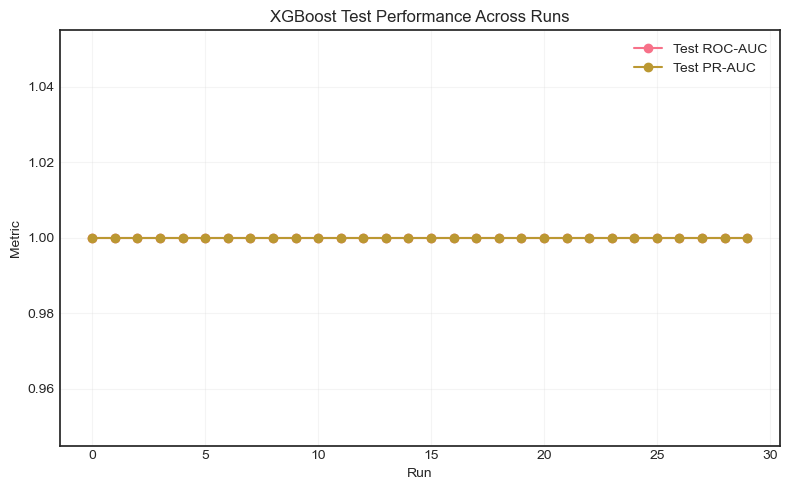

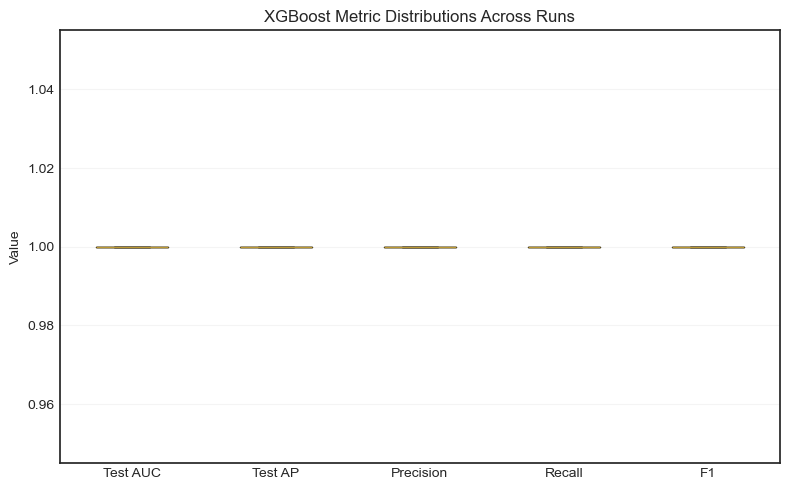


Saved:
- xgb_neg_sampling_30runs_results.csv
- xgb_neg_sampling_30runs_summary.csv

Ready for next cell:
- results_df, summary_df
- xgb_models_per_run (per-run trained XGB model + feature cols)
- all_feature_df (all nodes, no prox/distance)


In [23]:
# ============================================================
# MULTI-RUN XGBOOST VERSION (REPRODUCIBLE, 30 RUNS, EXTRA METRICS)
# - Runs once per negative set
# - CV on train only, eval on held-out test
# - Stores per-run trained XGB model + feature cols for averaged ranking later
# - Builds all_feature_df once for scoring all nodes later (no prox/distance)
# - Reports ROC-AUC, PR-AUC, Accuracy, Precision, Recall, F1
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    accuracy_score
)

try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError(
        "xgboost is not installed in this environment. Install it with: pip install xgboost"
    ) from e

# -----------------------------
# Reproducibility
# -----------------------------
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# -----------------------------
# Preconditions
# -----------------------------
if "negative_gene_sets" not in globals():
    raise RuntimeError("negative_gene_sets not found. Run negative sampling cell first.")
if "positive_genes" not in globals():
    raise RuntimeError("positive_genes not found.")
if "G" not in globals():
    raise RuntimeError("G not found. Build network first.")

EXPECTED_RUNS = 30
N_RUNS = len(negative_gene_sets)
SPLIT_SEED = 42
CV_SEED = 42
N_SPLITS_CV = 3

if N_RUNS != EXPECTED_RUNS:
    print(f"Warning: expected {EXPECTED_RUNS} negative sets, but found {N_RUNS}. Running with {N_RUNS} sets.")

print(f"=== RUNNING XGBOOST FOR {N_RUNS} NEGATIVE SETS ===")

# -----------------------------
# Precompute centralities ONCE
# -----------------------------
deg_cent = nx.degree_centrality(G)
try:
    btw_cent = nx.betweenness_centrality(G)
except Exception:
    btw_cent = {n: 0.0 for n in G.nodes()}
try:
    clo_cent = nx.closeness_centrality(G)
except Exception:
    clo_cent = {n: 0.0 for n in G.nodes()}
clust = nx.clustering(G)

USE_DIST_PROX = "dist_to_pos" in globals()
PROX_ALPHA = 0.7

def extract_gene_features_clean(graph, gene):
    gene = str(gene)
    neighbors = list(graph.neighbors(gene))
    if not neighbors:
        return None

    neighbor_degrees = [graph.degree(n) for n in neighbors]
    neighbor_weights = [float(graph[gene][n].get("weight", 1.0)) for n in neighbors]

    row = {
        "gene": gene,
        "degree": graph.degree(gene),
        "clustering_coefficient": float(clust.get(gene, 0.0)),
        "neighbor_count": len(neighbors),
        "avg_neighbor_degree": float(np.mean(neighbor_degrees)),
        "max_neighbor_degree": float(np.max(neighbor_degrees)),
        "avg_edge_weight": float(np.mean(neighbor_weights)),
        "max_edge_weight": float(np.max(neighbor_weights)),
        "degree_centrality": float(deg_cent.get(gene, 0.0)),
        "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
        "closeness_centrality": float(clo_cent.get(gene, 0.0)),
    }

    pos_neighbors = [n for n in neighbors if graph.nodes[n].get("positive", 0) == 1]
    pos_weights = [float(graph[gene][n].get("weight", 1.0)) for n in pos_neighbors] if pos_neighbors else []
    total_w = float(np.sum(neighbor_weights))
    pos_w_sum = float(np.sum(pos_weights)) if pos_weights else 0.0
    row["pos_weight_fraction"] = pos_w_sum / (total_w + 1e-9)

    if USE_DIST_PROX:
        d = dist_to_pos.get(gene, np.inf)
        row["distance_to_positive"] = float(d) if not np.isinf(d) else np.inf
        row["prox"] = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))

    return row

# -----------------------------
# Build all_feature_df ONCE
# - keep same features as labeled, but drop prox/distance for ranking later
# -----------------------------
if "all_feature_df" not in globals():
    rows_all = []
    for g in sorted(G.nodes()):
        r = extract_gene_features_clean(G, g)
        if r is not None:
            r.pop("prox", None)
            r.pop("distance_to_positive", None)
            rows_all.append(r)
    all_feature_df = pd.DataFrame(rows_all)

# -----------------------------
# XGBoost model factory
# -----------------------------
def make_model():
    return XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        min_child_weight=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=GLOBAL_SEED,
        n_jobs=1,
        tree_method="hist"
    )

cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=CV_SEED)

# -----------------------------
# Storage
# -----------------------------
all_results = []
xgb_models_per_run = []

# ============================================================
# MAIN LOOP
# ============================================================
for run_id, negative_genes in enumerate(negative_gene_sets):
    print(f"\n================ RUN {run_id} ================")

    positive_genes_list = sorted(list(map(str, positive_genes)))
    negative_genes_list = sorted(list(map(str, negative_genes)))

    all_labeled = positive_genes_list + negative_genes_list
    genes_in_graph = [g for g in all_labeled if str(g) in G]

    missing = sorted(set(map(str, all_labeled)) - set(map(str, genes_in_graph)))
    if missing:
        print(f"Note: {len(missing)} labeled genes not found in graph (dropped).")

    # -----------------------------
    # Feature DF for labeled genes
    # -----------------------------
    rows = []
    for g in genes_in_graph:
        r = extract_gene_features_clean(G, g)
        if r is not None:
            rows.append(r)

    feature_df = pd.DataFrame(rows)
    pos_set = set(positive_genes_list)
    feature_df["label"] = feature_df["gene"].astype(str).apply(lambda g: 1 if g in pos_set else 0)

    if feature_df.empty:
        print("Warning: empty feature_df for this run. Skipping.")
        continue

    # -----------------------------
    # Data prep
    # -----------------------------
    X = feature_df.drop(columns=["gene", "label"]).replace([np.inf, -np.inf], np.nan).fillna(0)
    y = feature_df["label"].astype(int).values
    genes = feature_df["gene"].astype(str).values

    X_train, X_test, y_train, y_test, genes_train, genes_test = train_test_split(
        X, y, genes,
        test_size=0.2,
        random_state=SPLIT_SEED,
        stratify=y
    )

    # kept for compatibility, not required by XGBoost
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Drop prox features, same as your other classic models
    drop_cols = [c for c in ["prox", "distance_to_positive"] if c in X_train.columns]
    if drop_cols:
        X_train_noprox = X_train.drop(columns=drop_cols)
        X_test_noprox = X_test.drop(columns=drop_cols)

        scaler_np = StandardScaler()
        X_train_scaled_noprox = scaler_np.fit_transform(X_train_noprox)
        X_test_scaled_noprox = scaler_np.transform(X_test_noprox)
    else:
        X_train_noprox = X_train
        X_test_noprox = X_test
        scaler_np = scaler
        X_train_scaled_noprox = X_train_scaled
        X_test_scaled_noprox = X_test_scaled

    # -----------------------------
    # Train + evaluate
    # -----------------------------
    model = make_model()

    n_pos_tr = int((y_train == 1).sum())
    n_neg_tr = int((y_train == 0).sum())
    spw = (n_neg_tr / max(1, n_pos_tr))
    model.set_params(scale_pos_weight=float(spw))

    cv_scores = cross_val_score(model, X_train_noprox, y_train, cv=cv, scoring="roc_auc")

    model.fit(X_train_noprox, y_train)

    y_score = model.predict_proba(X_test_noprox)[:, 1]
    y_pred = (y_score >= 0.5).astype(int)

    test_auc = float(roc_auc_score(y_test, y_score))
    test_ap = float(average_precision_score(y_test, y_score))
    test_acc = float(accuracy_score(y_test, y_pred))

    p, r, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )

    all_results.append({
        "run": run_id,
        "model": "XGBoost",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "n_pos_train": int(np.sum(y_train)),
        "n_pos_test": int(np.sum(y_test)),
        "cv_auc_mean": float(cv_scores.mean()),
        "cv_auc_std": float(cv_scores.std()),
        "test_auc": test_auc,
        "test_ap": test_ap,
        "accuracy": test_acc,
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "scale_pos_weight_train": float(spw),
        "dropped_cols": ",".join(drop_cols) if drop_cols else ""
    })

    print(
        f"XGBoost            | CV AUC {cv_scores.mean():.3f}±{cv_scores.std():.3f} "
        f"| Test AUC {test_auc:.3f} | AP {test_ap:.3f} | "
        f"Acc {test_acc:.3f} | P {p:.3f} R {r:.3f} F1 {f1:.3f} | spw={spw:.2f}"
    )

    xgb_models_per_run.append({
        "run_id": run_id,
        "model_name": "XGBoost",
        "model": model,
        "feature_cols": list(X_train_noprox.columns),
        "best_model_scaled": False,
        "scaler_used": scaler_np,
        "positive_genes_list": positive_genes_list,
        "negative_genes_list": negative_genes_list,
        "dropped_cols": drop_cols
    })

# ============================
# SUMMARY
# ============================
results_df = pd.DataFrame(all_results)

summary_df = (
    results_df
    .groupby("model")
    .agg(
        runs=("run", "nunique"),
        cv_auc_mean=("cv_auc_mean", "mean"),
        cv_auc_std=("cv_auc_mean", "std"),
        test_auc_mean=("test_auc", "mean"),
        test_auc_std=("test_auc", "std"),
        test_ap_mean=("test_ap", "mean"),
        test_ap_std=("test_ap", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .reset_index()
    .round(3)
)

print("\n=== SUMMARY ACROSS RUNS (XGBoost) ===")
print(summary_df.to_string(index=False))

# -----------------------------
# Simple plots
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(results_df["run"], results_df["test_auc"], marker="o", label="Test ROC-AUC")
plt.plot(results_df["run"], results_df["test_ap"], marker="o", label="Test PR-AUC")
plt.xlabel("Run")
plt.ylabel("Metric")
plt.title("XGBoost Test Performance Across Runs")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
box_data = [
    results_df["test_auc"].values,
    results_df["test_ap"].values,
    results_df["precision"].values,
    results_df["recall"].values,
    results_df["f1"].values,
]
plt.boxplot(box_data, labels=["Test AUC", "Test AP", "Precision", "Recall", "F1"], showfliers=True)
plt.title("XGBoost Metric Distributions Across Runs")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# -----------------------------
# Save
# -----------------------------
results_df.to_csv("xgb_neg_sampling_30runs_results.csv", index=False)
summary_df.to_csv("xgb_neg_sampling_30runs_summary.csv", index=False)

print("\nSaved:")
print("- xgb_neg_sampling_30runs_results.csv")
print("- xgb_neg_sampling_30runs_summary.csv")

# Compatibility variables
best_model = xgb_models_per_run[-1]["model"]
best_model_scaled = xgb_models_per_run[-1]["best_model_scaled"]
scaler_used = xgb_models_per_run[-1]["scaler_used"]
train_feature_cols_used = xgb_models_per_run[-1]["feature_cols"]
positive_genes_list = xgb_models_per_run[-1]["positive_genes_list"]
negative_genes_list = xgb_models_per_run[-1]["negative_genes_list"]

print("\nReady for next cell:")
print("- results_df, summary_df")
print("- xgb_models_per_run (per-run trained XGB model + feature cols)")
print("- all_feature_df (all nodes, no prox/distance)")

=== SCORE TIES + SCORE DISTRIBUTIONS (MULTI-RUN, XGBOOST READY, NO PROX FEATURES) ===

[RUN 0] Unlabeled genes: 814
[RUN 0] Unique unlabeled scores: 66
[RUN 0] Top score: 0.978469 | Unlabeled genes at top score: 164
[RUN 0] Unlabeled rows with duplicated feature vectors: 2 / 814

Most frequent unlabeled score values (top 10):
model_score
0.978469    164
0.020997    149
0.977240    145
0.976258     52
0.977539     37
0.021905     29
0.976226     19
0.024232     19
0.021696     17
0.178718     12


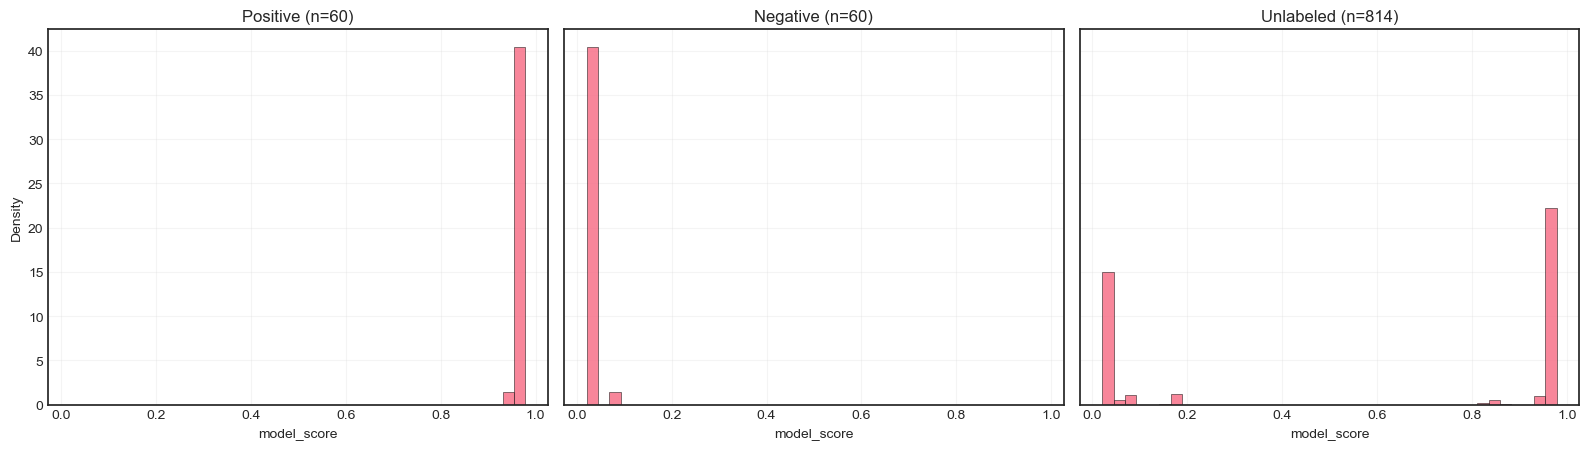


Top 20 unlabeled (RUN 0, with tie-breakers, no prox/distance):
 rank    gene  model_score  pos_weight_fraction  degree  max_neighbor_degree
    1  CCL3L1     0.978469             1.000000       6                 67.0
    2   HTR1D     0.978469             0.703928      16                 55.0
    3    TLR7     0.978469             0.690905      10                 67.0
    4   SSTR5     0.978469             0.659966       6                 55.0
    5 TNFRSF8     0.978469             0.613280       5                 60.0
    6    SGK1     0.978469             0.612948       6                 38.0
    7   CRHBP     0.978469             0.589581       5                 35.0
    8     DBH     0.978469             0.586829      17                 55.0
    9    MC3R     0.978469             0.578086       5                 55.0
   10     VGF     0.978469             0.577944       7                 87.0
   11    DRD3     0.978469             0.569128      13                 87.0
   12   TBX2

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

print("=== SCORE TIES + SCORE DISTRIBUTIONS (MULTI-RUN, XGBOOST READY, NO PROX FEATURES) ===")

# -----------------------------
# 0) Preconditions
# -----------------------------
if "xgb_models_per_run" not in globals() or len(xgb_models_per_run) == 0:
    raise NameError("xgb_models_per_run not found. Run the XGBoost multi-run training cell first.")

if "all_feature_df" not in globals():
    raise NameError("all_feature_df not found. The training cell should have built it.")

if "G" not in globals():
    raise NameError("G not found. Build the network first.")

if "positive_genes" not in globals():
    raise NameError("positive_genes not found.")

# Choose which run to visualize (0..N-1)
RUN_TO_SHOW = 0
if RUN_TO_SHOW < 0 or RUN_TO_SHOW >= len(xgb_models_per_run):
    raise ValueError(f"RUN_TO_SHOW must be in [0, {len(xgb_models_per_run)-1}]")

# If True: also compute consensus ranking across ALL runs (mean/std score per gene)
COMPUTE_CONSENSUS = True

# If True: define negatives as the union across all runs for grouping
USE_NEGATIVE_UNION = False

# -----------------------------
# 1) Pull run-specific model + feature columns
# -----------------------------
run_pack = xgb_models_per_run[RUN_TO_SHOW]
best_model = run_pack["model"]
best_model_scaled = bool(run_pack.get("best_model_scaled", False))   # should be False for XGB
scaler_used = run_pack.get("scaler_used", None)
train_feature_cols_used = list(run_pack["feature_cols"])

positive_genes_list = list(map(str, positive_genes))

if USE_NEGATIVE_UNION:
    negative_union = set()
    for rp in xgb_models_per_run:
        negative_union.update(map(str, rp["negative_genes_list"]))
    neg_set = negative_union
else:
    negative_genes_list = list(map(str, run_pack["negative_genes_list"]))
    neg_set = set(negative_genes_list)

pos_set = set(positive_genes_list)

def assign_group(g):
    g = str(g)
    if g in pos_set:
        return "positive"
    if g in neg_set:
        return "negative"
    return "unlabeled"

# -----------------------------
# 2) Build scoring matrix using the SAME features used in training
# -----------------------------
all_df = all_feature_df.copy()
all_df["gene"] = all_df["gene"].astype(str)
all_df["group"] = all_df["gene"].apply(assign_group)

# IMPORTANT: restrict to the exact train features
X_feat = all_df.reindex(columns=train_feature_cols_used, fill_value=0).copy()
X_feat = X_feat.replace([np.inf, -np.inf], np.nan).fillna(0)

# -----------------------------
# 3) Score all nodes (run-specific model)
# -----------------------------
if best_model_scaled:
    if scaler_used is None:
        raise RuntimeError("best_model_scaled=True but scaler_used is missing.")
    X_eval = scaler_used.transform(X_feat)
else:
    X_eval = X_feat.values

if hasattr(best_model, "predict_proba"):
    scores_all = best_model.predict_proba(X_eval)[:, 1]
else:
    scores_all = best_model.decision_function(X_eval)

scores_all = np.asarray(scores_all, dtype=float)
all_df["model_score"] = scores_all

# -----------------------------
# 4) Tie diagnostics (unlabeled only)
# -----------------------------
unl = all_df[all_df["group"] == "unlabeled"].copy()
n_unl = len(unl)
n_unique = unl["model_score"].nunique(dropna=False)
top_score = float(unl["model_score"].max()) if n_unl else np.nan
n_at_top = int((unl["model_score"] == top_score).sum()) if n_unl else 0

dup_mask = pd.DataFrame(X_feat, index=all_df.index).loc[unl.index].duplicated(keep=False)
n_dup = int(dup_mask.sum()) if n_unl else 0

print(f"\n[RUN {RUN_TO_SHOW}] Unlabeled genes: {n_unl}")
print(f"[RUN {RUN_TO_SHOW}] Unique unlabeled scores: {n_unique}")
print(f"[RUN {RUN_TO_SHOW}] Top score: {top_score:.6f} | Unlabeled genes at top score: {n_at_top}")
print(f"[RUN {RUN_TO_SHOW}] Unlabeled rows with duplicated feature vectors: {n_dup} / {n_unl}")

if n_unl:
    print("\nMost frequent unlabeled score values (top 10):")
    print(unl["model_score"].value_counts().head(10).to_string())

# -----------------------------
# 5) Score distributions (pos/neg/unlabeled)
# -----------------------------
pos_scores = all_df.loc[all_df["group"] == "positive", "model_score"].values
neg_scores = all_df.loc[all_df["group"] == "negative", "model_score"].values
unl_scores = all_df.loc[all_df["group"] == "unlabeled", "model_score"].values

all_scores = all_df["model_score"].values if len(all_df) else np.array([])
lo, hi = np.quantile(all_scores, [0.01, 0.99]) if len(all_scores) else (0.0, 1.0)
if lo == hi:
    lo, hi = float(np.min(all_scores)), float(np.max(all_scores))
pad = 0.05 * (hi - lo + 1e-9)
x_min, x_max = lo - pad, hi + pad
bins = np.linspace(x_min, x_max, 45)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True)

axes[0].hist(pos_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[0].set_title(f"Positive (n={len(pos_scores)})")
axes[0].set_xlabel("model_score")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.2)

axes[1].hist(neg_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[1].set_title(f"Negative (n={len(neg_scores)})")
axes[1].set_xlabel("model_score")
axes[1].grid(alpha=0.2)

axes[2].hist(unl_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[2].set_title(f"Unlabeled (n={len(unl_scores)})")
axes[2].set_xlabel("model_score")
axes[2].grid(alpha=0.2)

for ax in axes:
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

# -----------------------------
# 6) Ranked candidates (RUN_TO_SHOW)
# -----------------------------
rank_df = all_df[all_df["group"] == "unlabeled"][["gene", "model_score"]].copy()

tie_cols = [c for c in ["pos_weight_fraction", "degree", "max_neighbor_degree"] if c in all_df.columns]
for c in tie_cols:
    rank_df[c] = all_df.loc[rank_df.index, c].values

sort_cols = ["model_score"] + tie_cols + ["gene"]
ascending = [False] + [False] * len(tie_cols) + [True]
rank_df = rank_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
rank_df["rank"] = np.arange(1, len(rank_df) + 1)

print(f"\nTop 20 unlabeled (RUN {RUN_TO_SHOW}, with tie-breakers, no prox/distance):")
show_cols = ["rank", "gene", "model_score"] + tie_cols
print(rank_df.head(20)[show_cols].to_string(index=False))

# -----------------------------
# 7) Optional: CONSENSUS ranking across ALL runs (mean/std)
# -----------------------------
if COMPUTE_CONSENSUS:
    print("\n=== CONSENSUS RANKING ACROSS ALL RUNS (mean/std of model_score per gene) ===")

    score_frames = []
    for rp in xgb_models_per_run:
        m = rp["model"]
        cols = list(rp["feature_cols"])
        scaled = bool(rp.get("best_model_scaled", False))
        sc = rp.get("scaler_used", None)

        Xr = all_feature_df.reindex(columns=cols, fill_value=0).replace([np.inf, -np.inf], np.nan).fillna(0)
        Xr_eval = sc.transform(Xr) if scaled else Xr.values

        if hasattr(m, "predict_proba"):
            s = m.predict_proba(Xr_eval)[:, 1]
        else:
            s = m.decision_function(Xr_eval)

        score_frames.append(pd.DataFrame({
            "gene": all_feature_df["gene"].astype(str).values,
            f"score_run_{rp['run_id']}": np.asarray(s, dtype=float)
        }))

    consensus = score_frames[0]
    for sf in score_frames[1:]:
        consensus = consensus.merge(sf, on="gene", how="inner")

    consensus = consensus.merge(all_df[["gene", "group"]], on="gene", how="left")

    score_cols = [c for c in consensus.columns if c.startswith("score_run_")]
    consensus["score_mean"] = consensus[score_cols].mean(axis=1)
    consensus["score_std"] = consensus[score_cols].std(axis=1)

    cons_rank = consensus[consensus["group"] == "unlabeled"][["gene", "score_mean", "score_std"]].copy()
    cons_rank = cons_rank.sort_values(["score_mean", "score_std", "gene"], ascending=[False, True, True]).reset_index(drop=True)
    cons_rank["rank"] = np.arange(1, len(cons_rank) + 1)

    print("\nTop 20 unlabeled (CONSENSUS mean score; lower std breaks ties):")
    print(cons_rank.head(20)[["rank", "gene", "score_mean", "score_std"]].to_string(index=False))

    consensus_rank_df = cons_rank
    print("\nSaved variable: consensus_rank_df")

    out_path = "Results/MDD_XGBOOST_results2.csv"
    consensus_rank_df.to_csv(out_path, index=False)
    print(f"\nSaved unlabeled candidate genes to: {out_path}")
    